# YOLO-OBB Boat Detection — Model Evaluation

| Section | Description |
|---------|-------------|
| 1. Setup | Imports, paths, constants |
| 2. Training Curves | Loss, mAP, P/R from results.csv with overfitting diagnosis |
| 3. Model Loading | Load best YOLO-OBB checkpoint |
| 4. Confidence Threshold Search | Grid search over confidence values to maximise mAP |
| 5. Test-Set Evaluation | Final metrics at optimal threshold |
| 6. Per-Class Performance Table | Precision, Recall, F1, mAP per class |
| 7. Confusion Matrix | Normalised inter-class confusion |
| 8. Dataset Statistics | Class distribution across splits |
| 9. Object Size Analysis | Geometric statistics per class (OBB) |
| 10. Size × Performance Correlation | Spearman ρ between size/count and mAP |

## 1. Setup

In [1]:
import logging
import os
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
from ultralytics import YOLO

logging.getLogger("ultralytics").setLevel(logging.ERROR)

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.prop_cycle": plt.cycler(color=[
        "#4fc3f7", "#ef5350", "#66bb6a", "#ffa726",
        "#ab47bc", "#26c6da", "#d4e157", "#ff7043"
    ]),
    "font.size": 11,
})

# ── Paths ─────────────────────────────────────────────────────────────────────
MODEL_PATH    = Path("runs/obb/runs/obb/boat_obb_v1/weights/best.pt")
DATA_PATH     = Path("data/dataset.yaml")
PROCESSED_DIR = Path("data/processed")
RESULTS_CSV   = Path("runs/obb/runs/obb/boat_obb_v1/results.csv")  # training log

# ── Constants ─────────────────────────────────────────────────────────────────
IMG_SIZE    = 1536
TILE_SIZE   = 1536
SPLITS      = ["train", "val", "test"]
LABELS_ROOT = PROCESSED_DIR / "labels"

print(f"Model   : {MODEL_PATH}")
print(f"Dataset : {DATA_PATH}")
print(f"Results : {RESULTS_CSV}")

Model   : runs/obb/runs/obb/boat_obb_v1/weights/best.pt
Dataset : data/dataset.yaml
Results : runs/obb/runs/obb/boat_obb_v1/results.csv


## 2. Training Curves

Parsed from `results.csv`.  
The **Classification Loss** divergence between train and val is the primary overfitting signal for a multi-class detection model.  
A white dashed vertical line marks the epoch of **best mAP50**; a yellow dashed line marks where **val cls loss** was at its minimum.

  Epochs run       : 140
  Avg time / epoch : 1.3 min
  Best mAP@50      : 0.3963  (epoch 10)
  Best mAP@50:95   : 0.2903
  Val cls loss min : epoch 13  →  diverged +67% by epoch 140


/tmp/ipykernel_8935/854215041.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


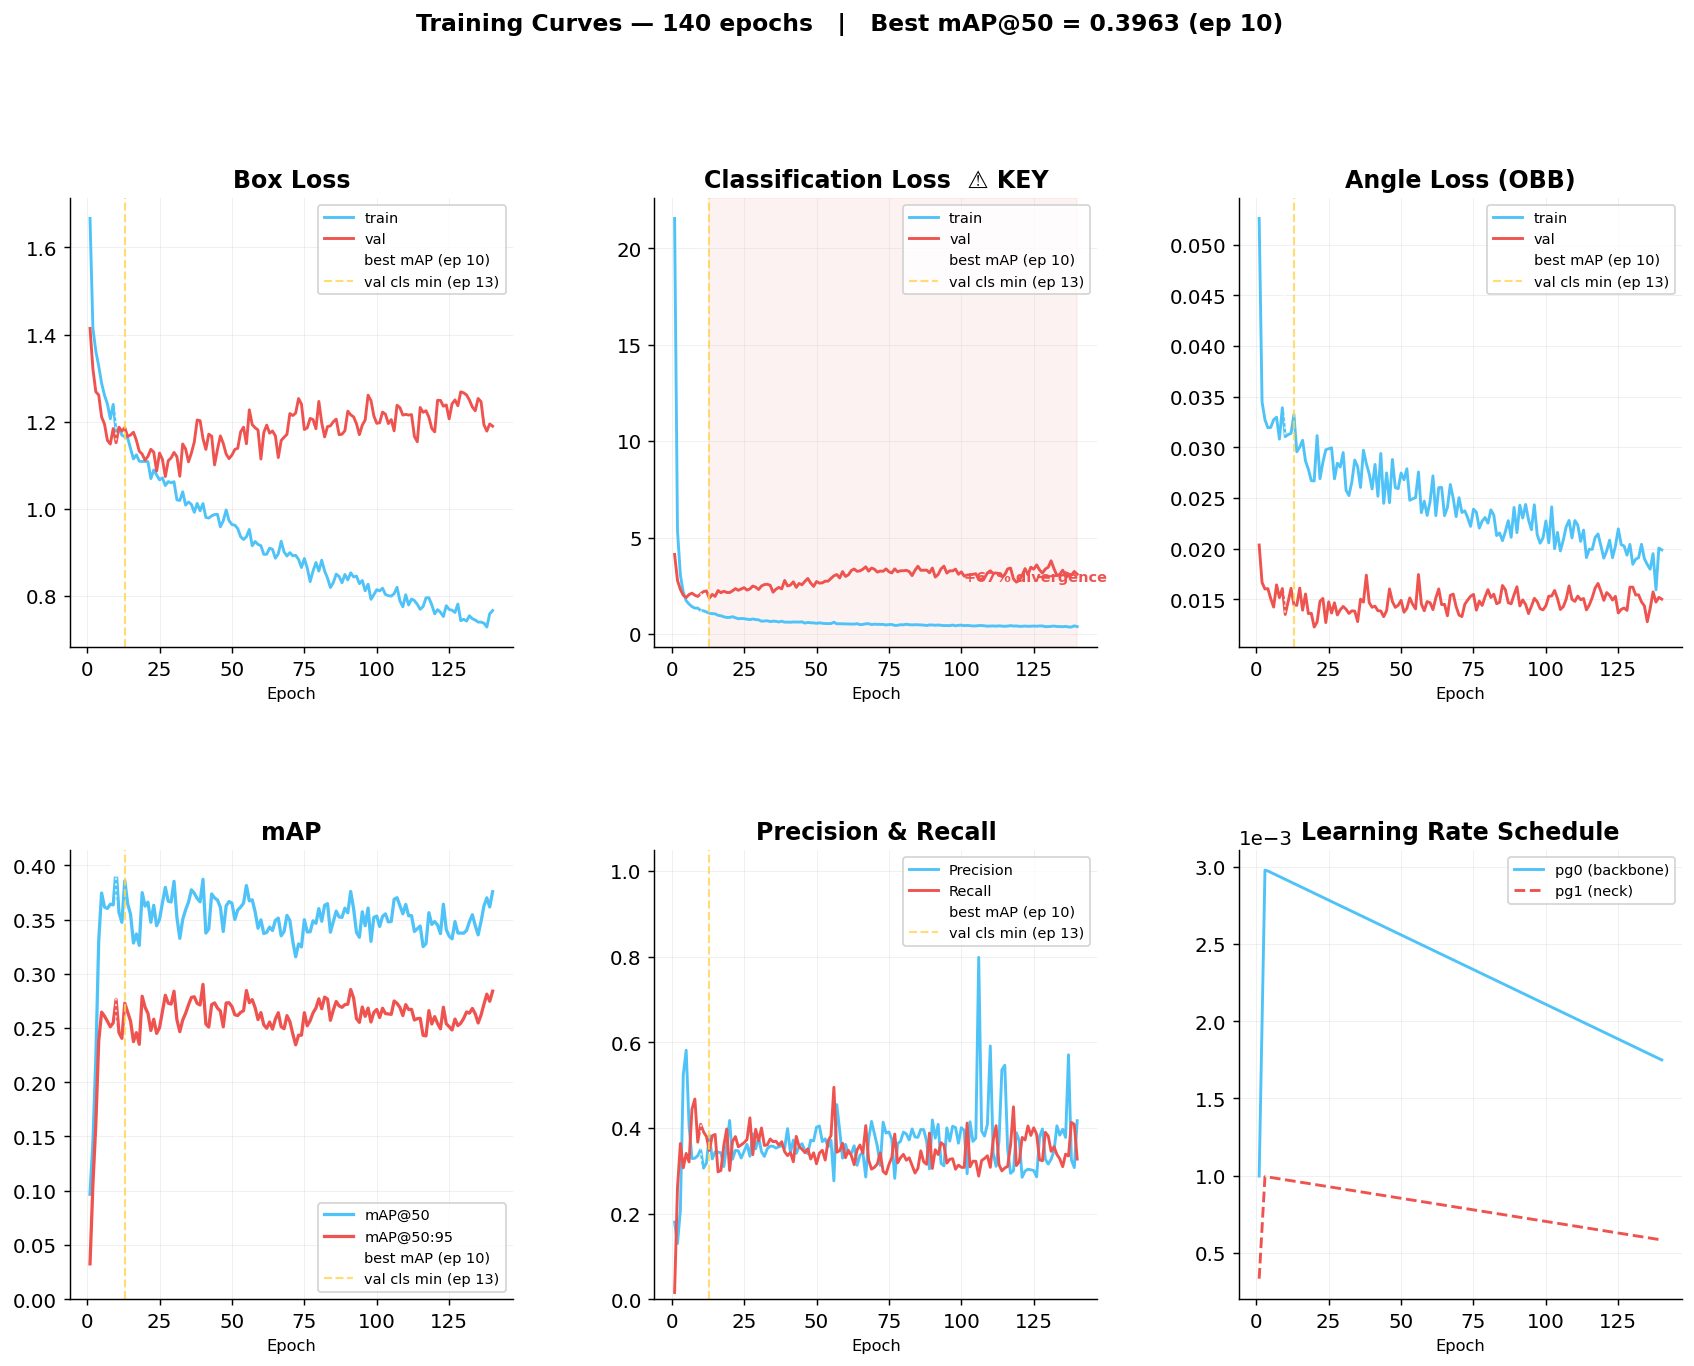


── Diagnosis ──────────────────────────────────────────
  Val cls loss peaked at epoch 13, then rose +67%.
  This is classic classification-head overfitting.
  Box/angle losses still converging → geometry learning is healthy.
  Recommended action: use best.pt (epoch 10) + add label_smoothing=0.1
────────────────────────────────────────────────────────


In [2]:
df_tr = pd.read_csv(RESULTS_CSV)
df_tr.columns = df_tr.columns.str.strip()

best_map_idx   = df_tr["metrics/mAP50(B)"].idxmax()
best_epoch     = int(df_tr.loc[best_map_idx, "epoch"])
best_map50     = df_tr.loc[best_map_idx, "metrics/mAP50(B)"]
best_map5095   = df_tr["metrics/mAP50-95(B)"].max()
cls_min_epoch  = int(df_tr["val/cls_loss"].idxmin()) + 1
cls_divergence = (df_tr["val/cls_loss"].iloc[-1] - df_tr["val/cls_loss"].min()) / df_tr["val/cls_loss"].min() * 100
total_epochs   = len(df_tr)
epoch_time_min = (df_tr["time"].iloc[-1] - df_tr["time"].iloc[0]) / (total_epochs - 1) / 60

print(f"  Epochs run       : {total_epochs}")
print(f"  Avg time / epoch : {epoch_time_min:.1f} min")
print(f"  Best mAP@50      : {best_map50:.4f}  (epoch {best_epoch})")
print(f"  Best mAP@50:95   : {best_map5095:.4f}")
print(f"  Val cls loss min : epoch {cls_min_epoch}  →  diverged +{cls_divergence:.0f}% by epoch {total_epochs}")

e   = df_tr["epoch"]
C   = ["#4fc3f7", "#ef5350"]   # train / val
ALT = "#ffd54f"                # secondary marker

fig = plt.figure(figsize=(16, 11))
fig.suptitle(f"Training Curves — {total_epochs} epochs   |   Best mAP@50 = {best_map50:.4f} (ep {best_epoch})",
             fontsize=13, fontweight="bold", y=1.01)
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.32)

def _vlines(ax):
    ax.axvline(best_epoch,   color="white",  lw=1.2, ls=":",  alpha=0.7, label=f"best mAP (ep {best_epoch})")
    ax.axvline(cls_min_epoch, color=ALT, lw=1.2, ls="--", alpha=0.8, label=f"val cls min (ep {cls_min_epoch})")

# 1 — Box loss
ax = fig.add_subplot(gs[0, 0])
ax.plot(e, df_tr["train/box_loss"], color=C[0], lw=1.6, label="train")
ax.plot(e, df_tr["val/box_loss"],   color=C[1], lw=1.6, label="val")
_vlines(ax)
ax.set_title("Box Loss", fontweight="bold")
ax.legend(fontsize=8)

# 2 — Classification loss  (key chart)
ax = fig.add_subplot(gs[0, 1])
ax.plot(e, df_tr["train/cls_loss"], color=C[0], lw=1.6, label="train")
ax.plot(e, df_tr["val/cls_loss"],   color=C[1], lw=1.6, label="val")
_vlines(ax)
ax.axvspan(cls_min_epoch, e.max(), alpha=0.07, color="#ef5350")
ax.set_title("Classification Loss  ⚠ KEY", fontweight="bold")
ax.legend(fontsize=8)
ax.annotate(f"+{cls_divergence:.0f}% divergence",
            xy=(e.max(), df_tr["val/cls_loss"].iloc[-1]),
            xytext=(e.max() * 0.72, df_tr["val/cls_loss"].iloc[-1] * 0.88),
            color="#ef5350", fontsize=8, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#ef5350", lw=1.2))

# 3 — Angle loss
ax = fig.add_subplot(gs[0, 2])
ax.plot(e, df_tr["train/angle_loss"], color=C[0], lw=1.6, label="train")
ax.plot(e, df_tr["val/angle_loss"],   color=C[1], lw=1.6, label="val")
_vlines(ax)
ax.set_title("Angle Loss (OBB)", fontweight="bold")
ax.legend(fontsize=8)

# 4 — mAP
ax = fig.add_subplot(gs[1, 0])
ax.plot(e, df_tr["metrics/mAP50(B)"],    lw=1.8, label="mAP@50")
ax.plot(e, df_tr["metrics/mAP50-95(B)"], lw=1.8, label="mAP@50:95")
ax.scatter([best_epoch], [best_map50], color="white", zorder=5, s=50)
_vlines(ax)
ax.set_ylim(0, None)
ax.set_title("mAP", fontweight="bold")
ax.legend(fontsize=8)

# 5 — Precision / Recall
ax = fig.add_subplot(gs[1, 1])
ax.plot(e, df_tr["metrics/precision(B)"], lw=1.6, label="Precision")
ax.plot(e, df_tr["metrics/recall(B)"],    lw=1.6, label="Recall")
_vlines(ax)
ax.set_ylim(0, 1.05)
ax.set_title("Precision & Recall", fontweight="bold")
ax.legend(fontsize=8)

# 6 — Learning rate
ax = fig.add_subplot(gs[1, 2])
ax.plot(e, df_tr["lr/pg0"], lw=1.6, label="pg0 (backbone)")
ax.plot(e, df_tr["lr/pg1"], lw=1.6, ls="--", label="pg1 (neck)")
ax.set_title("Learning Rate Schedule", fontweight="bold")
ax.legend(fontsize=8)
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

for ax_ in fig.axes:
    ax_.set_xlabel("Epoch", fontsize=9)
    ax_.grid(alpha=0.2, lw=0.5)

plt.tight_layout()
plt.show()

# ── Diagnosis summary ─────────────────────────────────────────────────────────
print("\n── Diagnosis ──────────────────────────────────────────")
print(f"  Val cls loss peaked at epoch {cls_min_epoch}, then rose +{cls_divergence:.0f}%.")
print(f"  This is classic classification-head overfitting.")
print(f"  Box/angle losses still converging → geometry learning is healthy.")
print(f"  Recommended action: use best.pt (epoch {best_epoch}) + add label_smoothing=0.1")
print("────────────────────────────────────────────────────────")

## 3. Model Loading

In [3]:
model = YOLO(MODEL_PATH)
CLASS_NAMES = model.names   # {id: name}

print("Classes:")
for cid, name in CLASS_NAMES.items():
    print(f"  [{cid}] {name}")

/home/thomas/miniconda3/envs/sam3_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Classes:
  [0] Pirogue
  [1] Double_hulled_Pirogue
  [2] Small_Motorboat
  [3] Medium_Motorboat
  [4] Large_Motorboat
  [5] Sailing_Boat


## 4. Confidence Threshold Search

Sweeps 25 confidence values in \[0.01, 0.90\] on the **test split** and records global + per-class mAP50-95.  
The optimal threshold maximises mean mAP50-95.  Results are cached for downstream cells.

> ⚠️ This cell is expensive (~25 full inference passes).

Global best → conf=0.3808  mAP50-95=0.2988  P=0.5508  R=0.3371



,Class,conf,mAP50-95,Precision,Recall
5,Small_Motorboat,0.1954,0.5952,0.8757,0.6880
0,Double_hulled_Pirogue,0.1583,0.5350,0.8736,0.7155
3,Pirogue,0.0842,0.3714,0.7130,0.3659
4,Sailing_Boat,0.3808,0.3127,0.8000,0.3333
1,Large_Motorboat,0.0100,0.0000,0.0000,0.0000
2,Medium_Motorboat,0.0842,0.0000,0.0000,0.0000


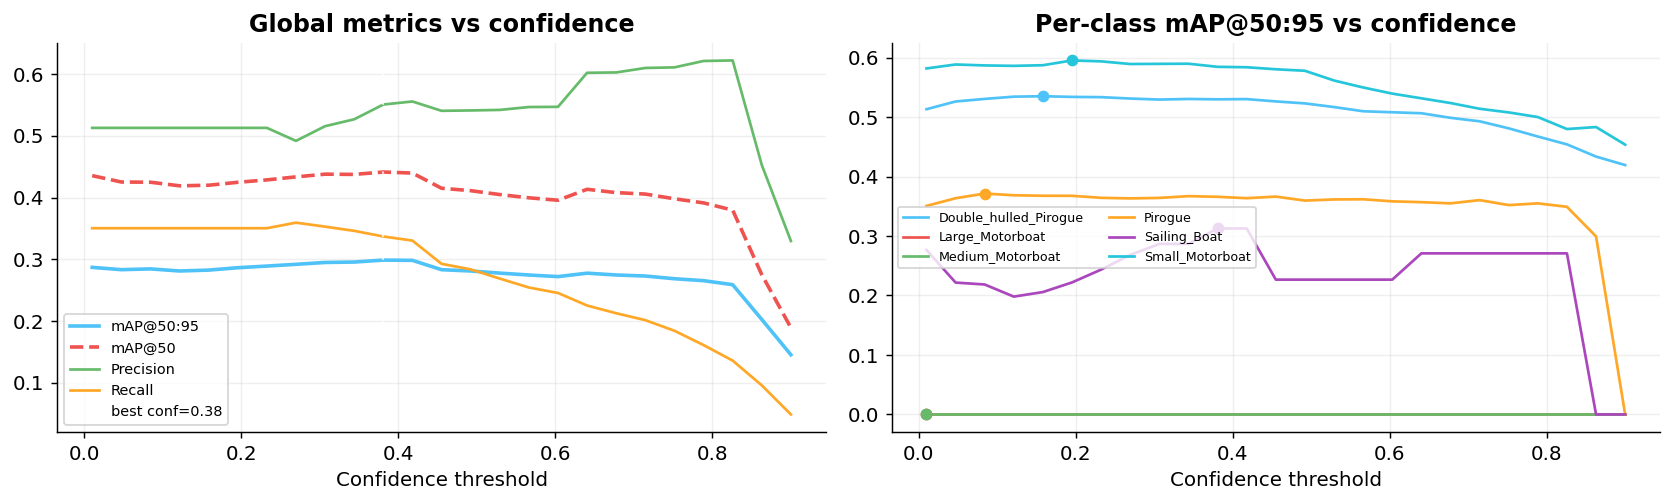

In [4]:
CONF_VALUES = np.linspace(0.01, 0.90, 25)
VAL_KWARGS  = dict(
    data=str(DATA_PATH), split="test", imgsz=TILE_SIZE,
    iou=0.3, plots=False, verbose=False,
    project="val", name="sweep", exist_ok=True,
)

global_rows    = []
per_class_rows = []

for conf in CONF_VALUES:
    m = model.val(conf=float(conf), **VAL_KWARGS)

    global_rows.append({
        "conf":      conf,
        "mAP50-95":  float(m.box.map),
        "mAP50":     float(m.box.map50),
        "Precision": float(m.box.mp),
        "Recall":    float(m.box.mr),
    })

    ap = m.box.ap
    if ap.ndim == 2:
        ap = ap.mean(axis=1)
    evaluated_cids = list(m.box.ap_class_index)

    for cid, name in CLASS_NAMES.items():
        if cid in evaluated_cids:
            idx    = evaluated_cids.index(cid)
            ap_val = float(ap[idx])
            p_val  = float(m.box.p[idx])
            r_val  = float(m.box.r[idx])
        else:
            ap_val = p_val = r_val = 0.0

        per_class_rows.append({
            "conf":      conf,
            "Class":     name,
            "mAP50-95":  ap_val,
            "Precision": p_val,
            "Recall":    r_val,
        })

df_global = pd.DataFrame(global_rows)
df_class  = pd.DataFrame(per_class_rows)

# ── Best thresholds ───────────────────────────────────────────────────────────
BEST_CONF: dict[str, float] = {}
for cls_name, grp in df_class.groupby("Class"):
    BEST_CONF[cls_name] = float(grp.loc[grp["mAP50-95"].idxmax(), "conf"])

best_global_row  = df_global.loc[df_global["mAP50-95"].idxmax()]
BEST_CONF["global"] = float(best_global_row["conf"])

best_per_class = (
    df_class.sort_values("mAP50-95", ascending=False)
            .groupby("Class", as_index=False).first()
            .sort_values("mAP50-95", ascending=False)
)

print(f"Global best → conf={BEST_CONF['global']:.4f}  "
      f"mAP50-95={best_global_row['mAP50-95']:.4f}  "
      f"P={best_global_row['Precision']:.4f}  R={best_global_row['Recall']:.4f}\n")

display(best_per_class[["Class", "conf", "mAP50-95", "Precision", "Recall"]].round(4))

# ── Plot: global mAP50-95 vs confidence ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(df_global["conf"], df_global["mAP50-95"],  lw=2, label="mAP@50:95")
ax.plot(df_global["conf"], df_global["mAP50"],     lw=2, ls="--", label="mAP@50")
ax.plot(df_global["conf"], df_global["Precision"], lw=1.5, label="Precision")
ax.plot(df_global["conf"], df_global["Recall"],    lw=1.5, label="Recall")
ax.axvline(BEST_CONF["global"], color="white", lw=1.2, ls=":", alpha=0.8,
           label=f"best conf={BEST_CONF['global']:.2f}")
ax.set_xlabel("Confidence threshold")
ax.set_title("Global metrics vs confidence", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

ax = axes[1]
for cls_name, grp in df_class.groupby("Class"):
    ax.plot(grp["conf"], grp["mAP50-95"], lw=1.5, label=cls_name)
    best_c = BEST_CONF[cls_name]
    best_v = grp.loc[grp["conf"].sub(best_c).abs().idxmin(), "mAP50-95"]
    ax.scatter([best_c], [best_v], s=30, zorder=5)
ax.set_xlabel("Confidence threshold")
ax.set_title("Per-class mAP@50:95 vs confidence", fontweight="bold")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 5. Test-Set Evaluation

Single full evaluation at the optimal global confidence threshold.

In [5]:
metrics = model.val(
    data=str(DATA_PATH),
    split="test",
    imgsz=IMG_SIZE,
    conf=BEST_CONF["global"],
    iou=0.3,
    plots=False,
    verbose=False,
)

print(f"Confidence : {BEST_CONF['global']:.4f}")
print(f"mAP@50     : {metrics.box.map50:.4f}")
print(f"mAP@50:95  : {metrics.box.map:.4f}")
print(f"Precision  : {metrics.box.mp:.4f}")
print(f"Recall     : {metrics.box.mr:.4f}")

Confidence : 0.3808
mAP@50     : 0.4415
mAP@50:95  : 0.2988
Precision  : 0.5508
Recall     : 0.3371


## 6. Per-Class Performance Table

Precision, Recall, F1, mAP50 and mAP50-95 per class alongside **Support** (GT instances in test set).  
Classes are sorted by mAP50-95 descending. The global row uses macro-averaging.

,Class,Support,Precision,Recall,F1-score,mAP50,mAP50-95
0,Small_Motorboat,126,0.880400,0.648000,0.746500,0.775800,0.584500
1,Double_hulled_Pirogue,496,0.896600,0.696900,0.784200,0.801200,0.529800
2,Pirogue,568,0.728000,0.344200,0.467400,0.521700,0.365900
3,Sailing_Boat,12,0.800000,0.333300,0.470600,0.550300,0.312700
4,Medium_Motorboat,8,0.000000,0.000000,0.000000,0.000000,0.000000
5,Large_Motorboat,4,0.000000,0.000000,0.000000,0.000000,0.000000
6,── Global ──,1214,0.550800,0.337100,0.418200,0.441500,0.298800


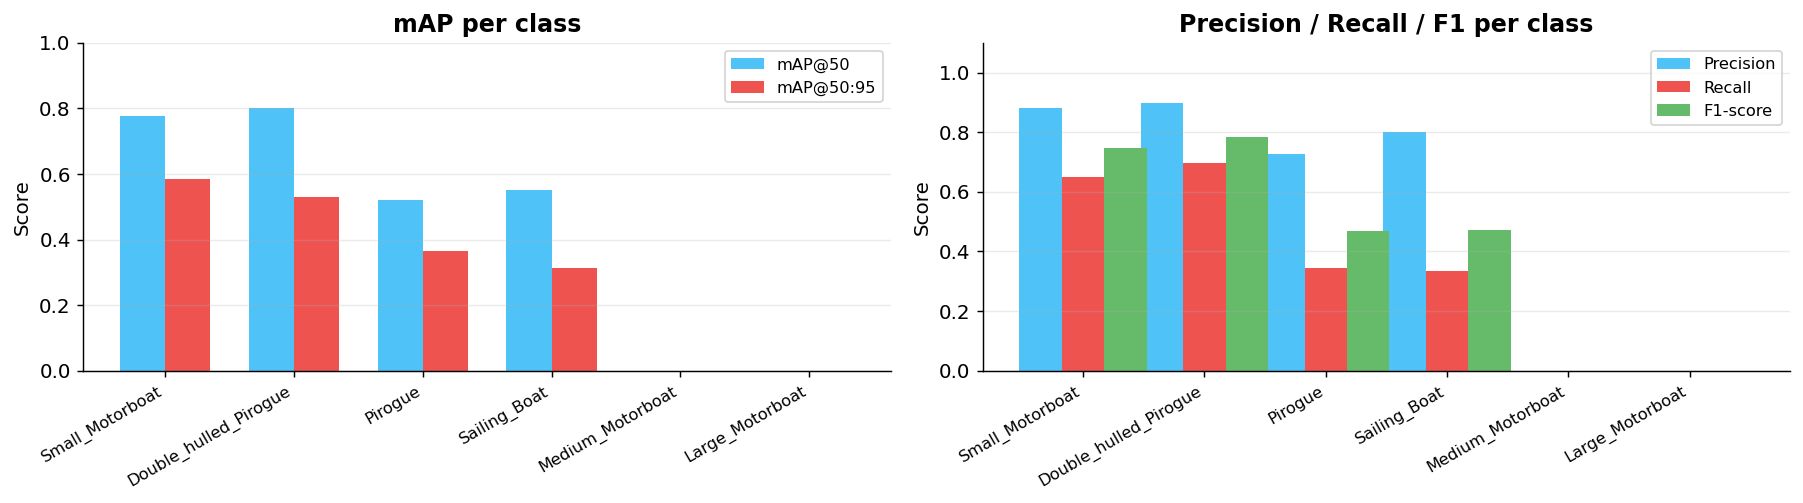

In [6]:
# ── Support ───────────────────────────────────────────────────────────────────
class_counter: Counter = Counter()
for txt in (LABELS_ROOT / "test").glob("*.txt"):
    for line in txt.read_text().splitlines():
        line = line.strip()
        if line:
            class_counter[int(line.split()[0])] += 1

support = [class_counter.get(i, 0) for i in range(len(CLASS_NAMES))]

# ── Per-class metrics ─────────────────────────────────────────────────────────
p_arr    = metrics.box.p
r_arr    = metrics.box.r
map_arr  = metrics.box.maps
ap50_arr = metrics.box.ap50 if hasattr(metrics.box, "ap50") else [np.nan] * len(CLASS_NAMES)

rows = []
for cid, name in CLASS_NAMES.items():
    p  = float(p_arr[cid])
    r  = float(r_arr[cid])
    f1 = 2 * p * r / (p + r + 1e-9)
    rows.append({
        "Class":     name,
        "Support":   support[cid],
        "Precision": p,
        "Recall":    r,
        "F1-score":  f1,
        "mAP50":     float(ap50_arr[cid]),
        "mAP50-95":  float(map_arr[cid]),
    })

p_g = float(metrics.box.mp)
r_g = float(metrics.box.mr)
rows.append({
    "Class":     "── Global ──",
    "Support":   sum(support),
    "Precision": p_g,
    "Recall":    r_g,
    "F1-score":  2 * p_g * r_g / (p_g + r_g + 1e-9),
    "mAP50":     float(metrics.box.map50),
    "mAP50-95":  float(metrics.box.map),
})

df_perf = pd.concat([
    pd.DataFrame(rows[:-1]).sort_values("mAP50-95", ascending=False),
    pd.DataFrame([rows[-1]]),
]).reset_index(drop=True)

display(
    df_perf.round(4).style
    .background_gradient(subset=["mAP50", "mAP50-95", "F1-score"], cmap="YlGn")
    .bar(subset=["Support"], color="#4fc3f7", vmin=0)
    .set_caption(f"Test-set metrics at conf={BEST_CONF['global']:.3f}")
)

# ── Visual bar chart ──────────────────────────────────────────────────────────
df_cls_only = df_perf[df_perf["Class"] != "── Global ──"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# mAP bar chart
ax = axes[0]
x  = np.arange(len(df_cls_only))
w  = 0.35
ax.bar(x - w/2, df_cls_only["mAP50"].values,    w, label="mAP@50")
ax.bar(x + w/2, df_cls_only["mAP50-95"].values, w, label="mAP@50:95")
ax.set_xticks(x)
ax.set_xticklabels(df_cls_only["Class"].values, rotation=30, ha="right", fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("mAP per class", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)

# P / R / F1 grouped bar
ax = axes[1]
ax.bar(x - w,   df_cls_only["Precision"].values, w, label="Precision")
ax.bar(x,       df_cls_only["Recall"].values,    w, label="Recall")
ax.bar(x + w,   df_cls_only["F1-score"].values,  w, label="F1-score")
ax.set_xticks(x)
ax.set_xticklabels(df_cls_only["Class"].values, rotation=30, ha="right", fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 per class", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### F1 vs Confidence (per class)

Shows how F1 evolves across the sweep for every class. Vertical dashes mark each class's peak.

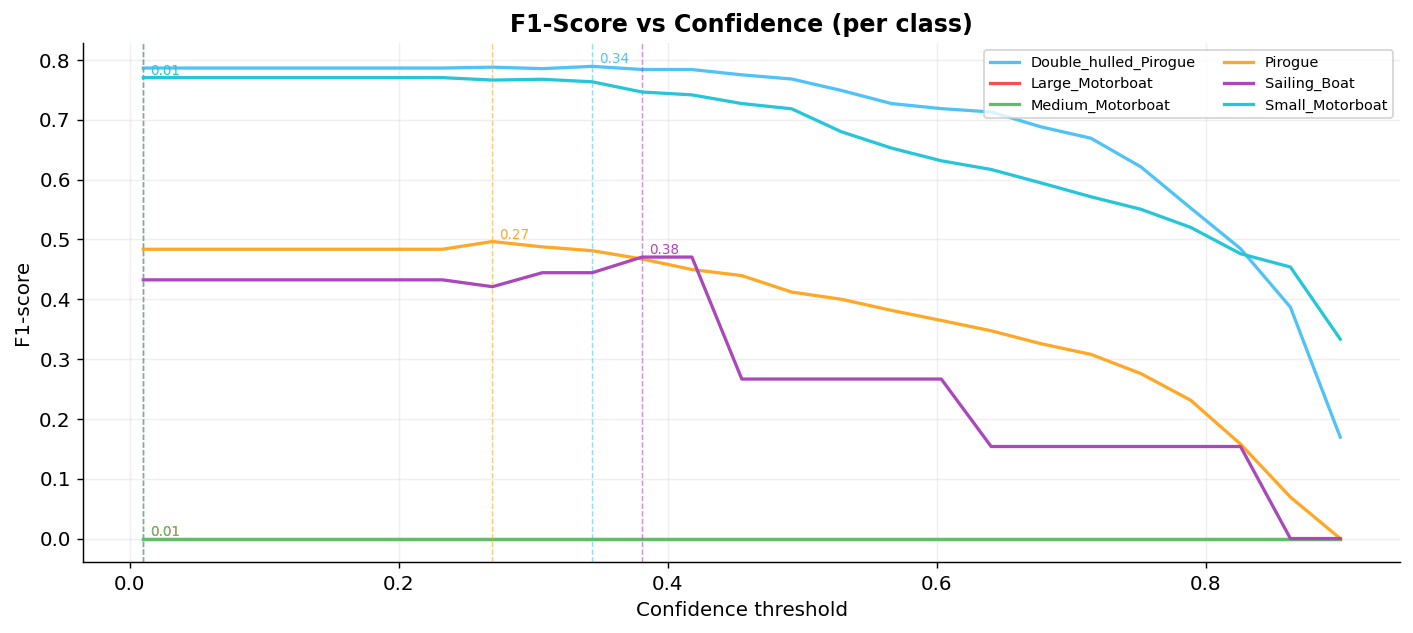

In [7]:
EPS = 1e-9
fig, ax = plt.subplots(figsize=(11, 5))

for cls_name, grp in df_class.groupby("Class"):
    f1 = 2 * grp["Precision"] * grp["Recall"] / (grp["Precision"] + grp["Recall"] + EPS)
    line, = ax.plot(grp["conf"].values, f1.values, lw=1.8, label=cls_name)
    best_idx = f1.idxmax()
    best_c   = grp.loc[best_idx, "conf"]
    best_f1  = f1.loc[best_idx]
    ax.axvline(best_c, color=line.get_color(), lw=0.8, ls="--", alpha=0.6)
    ax.text(best_c + 0.005, best_f1, f"{best_c:.2f}",
            color=line.get_color(), fontsize=7.5, va="bottom")

ax.set_xlabel("Confidence threshold")
ax.set_ylabel("F1-score")
ax.set_title("F1-Score vs Confidence (per class)", fontweight="bold")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 7. Confusion Matrix

Row-normalised confusion matrix (each row sums to 1).  
The last row/column represents background (missed detections / false positives).

  Confusion matrix sum (should be >> 0): 0
  [WARN] Matrix is still all-zero. Check that:
         - test/ images and labels directories are not empty
         - dataset.yaml paths point to the correct split
         - the model weights loaded are actually trained (not random init)


NameError: name 'CM_CONF' is not defined

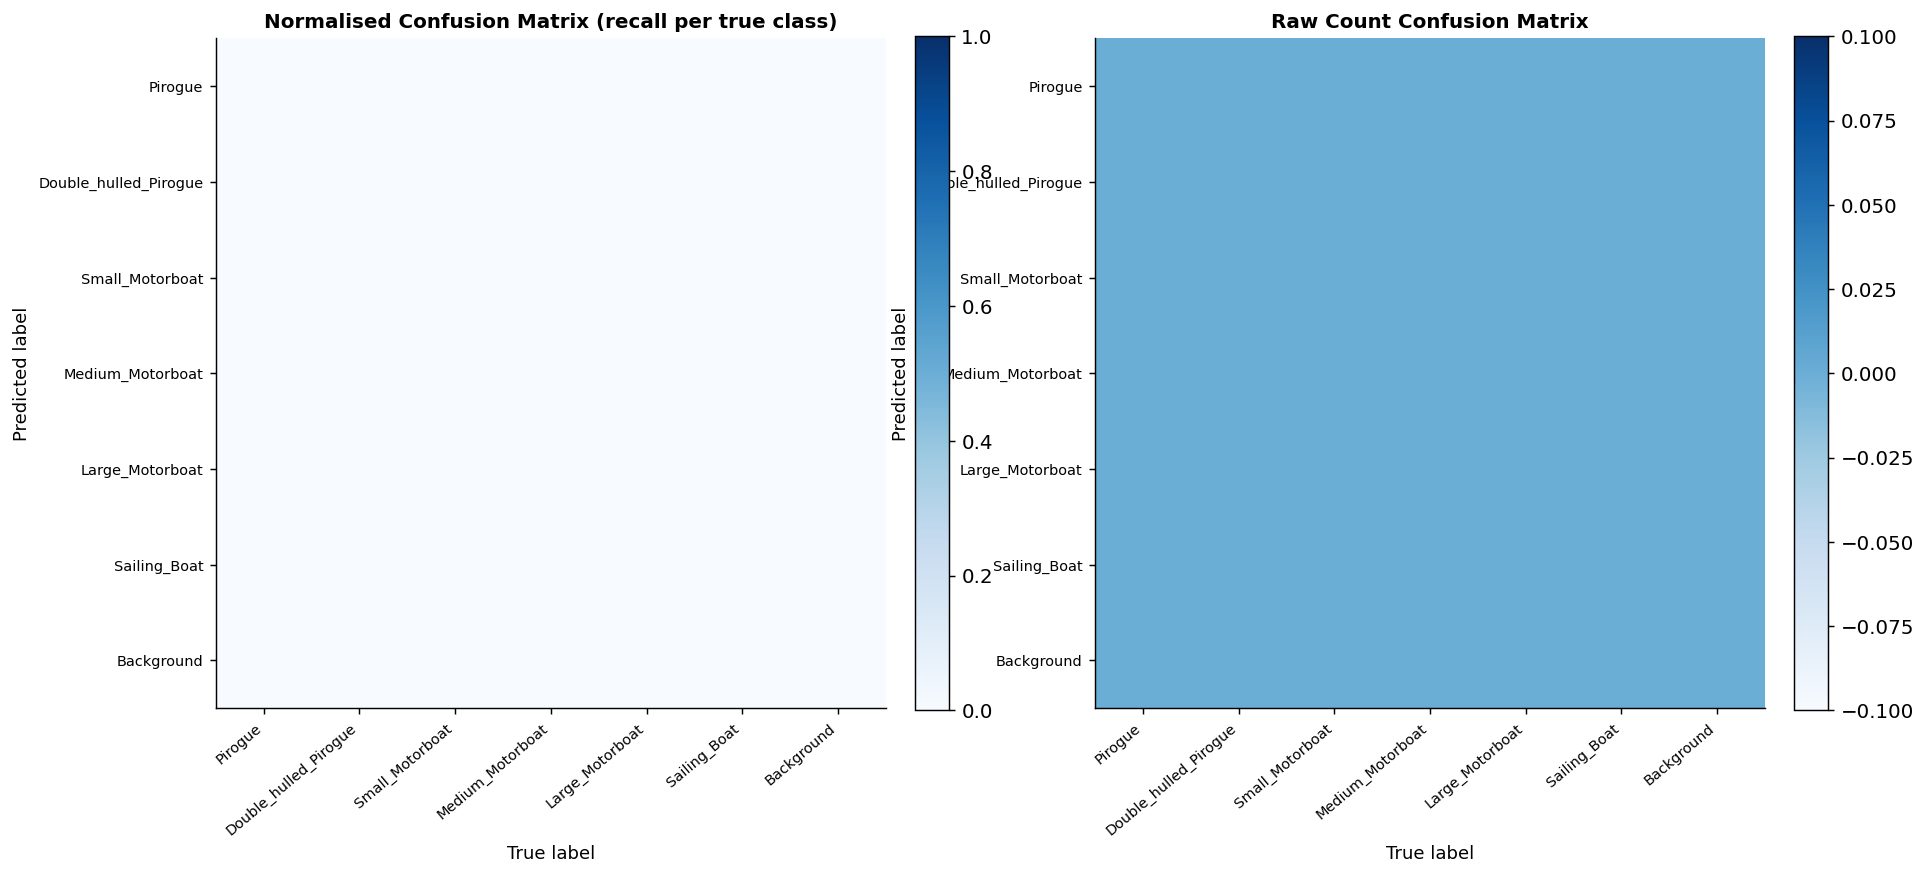

In [ ]:
# =============================================================================
# Confusion matrix evaluation
# =============================================================================

metrics_cm = model.val(
    data    = str(DATA_PATH),
    split   = "test",
    imgsz   = TILE_SIZE,          
    conf    = BEST_CONF["global"],
    iou     = 0.3,
    plots   = False,
    verbose = False,
)

# Sanity check — if still zero after the fix, something is wrong with the
# test split itself (empty labels, wrong path, etc.)
matrix_sum = metrics_cm.confusion_matrix.matrix.sum()
print(f"  Confusion matrix sum (should be >> 0): {matrix_sum:.0f}")
if matrix_sum == 0:
    print("  [WARN] Matrix is still all-zero. Check that:")
    print("         - test/ images and labels directories are not empty")
    print("         - dataset.yaml paths point to the correct split")
    print("         - the model weights loaded are actually trained (not random init)")

cm_raw  = metrics_cm.confusion_matrix.matrix          # (nc+1, nc+1)

cm_norm = cm_raw / (cm_raw.sum(axis=0, keepdims=True) + 1e-9)


labels_with_bg = list(CLASS_NAMES.values()) + ["Background"]
nc1 = len(labels_with_bg)                             # nc + 1


# =============================================================================
# Plot
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, mat, title, fmt, vmax in zip(
    axes,
    [cm_norm, cm_raw],
    ["Normalised Confusion Matrix (recall per true class)",
     "Raw Count Confusion Matrix"],
    [".2f", ".0f"],
    [1.0, cm_raw.max()],
):
    im = ax.imshow(mat, vmin=0, vmax=vmax, cmap="Blues")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(range(nc1))
    ax.set_xticklabels(labels_with_bg, rotation=40, ha="right", fontsize=8)
    ax.set_yticks(range(nc1))
    ax.set_yticklabels(labels_with_bg, fontsize=8)

    thresh = vmax / 2.0
    for i in range(nc1):
        for j in range(nc1):
            v = mat[i, j]
            if not np.isnan(v) and v > 0:
                color = "white" if v > thresh else "black"
                ax.text(j, i, format(v, fmt),
                        ha="center", va="center", fontsize=7.5, color=color)

    # Ultralytics convention: rows = predicted, columns = true
    ax.set_ylabel("Predicted label", fontsize=10)
    ax.set_xlabel("True label",      fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")

plt.suptitle(
    f"conf={CM_CONF:.3f}  |  IoU=0.3  |  split=test",
    fontsize=10, y=1.01,
)
plt.tight_layout()
plt.show()

# =============================================================================
# Per-class miss-rate (FN → Background)
# =============================================================================

print(f"\nMiss-rate (FN → Background) per class  [conf={BEST_CONF['global']:.3f}]:")
nc = len(CLASS_NAMES)
for j, name in enumerate(CLASS_NAMES.values()):
    col_total = cm_raw[:, j].sum()
    missed    = cm_raw[nc, j]           # Background row, true-class column
    miss_rate = missed / (col_total + 1e-9)
    print(f"  {name:<28} {miss_rate*100:5.1f}%  ({int(missed)}/{int(col_total)})")

## 8. Dataset Statistics

Class distribution and balance across train / val / test splits.

Object counts per class and split:


,Class,Train,Val,Test,Total
0,Pirogue,1984,666,568,3218
1,Double_hulled_Pirogue,2163,98,496,2757
2,Small_Motorboat,917,288,126,1331
3,Medium_Motorboat,284,211,8,503
4,Large_Motorboat,72,40,4,116
5,Sailing_Boat,365,16,12,393


  train   5785 objects  1018/1131 annotated tiles
  val     1319 objects   134/148 annotated tiles
  test    1214 objects   307/341 annotated tiles


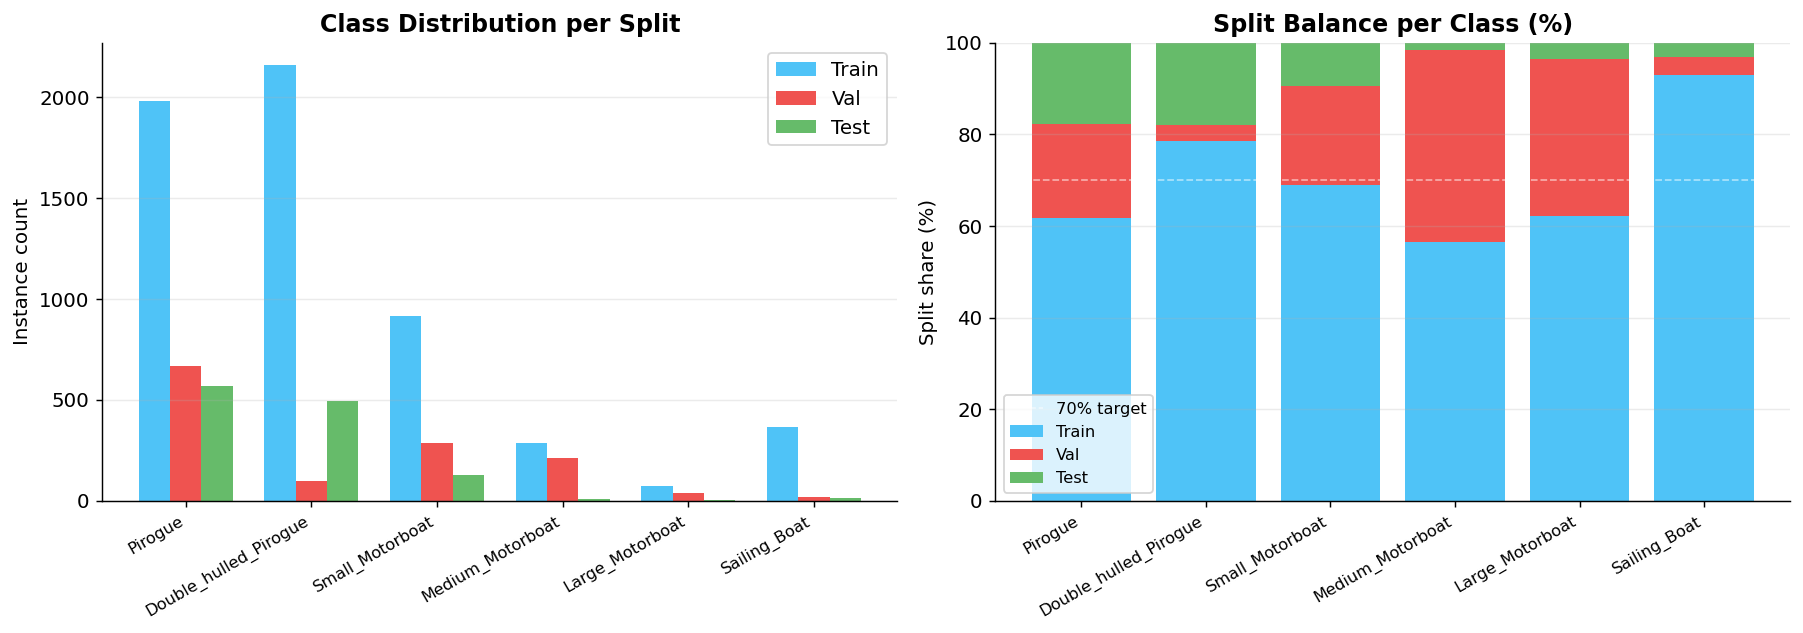

In [9]:
def count_split(labels_dir: Path) -> tuple[dict, int, int]:
    counts: dict[int, int] = defaultdict(int)
    annotated = 0
    txt_files = list(labels_dir.glob("*.txt"))
    for txt in txt_files:
        lines = [l.strip() for l in txt.read_text().splitlines() if l.strip()]
        if lines:
            annotated += 1
        for line in lines:
            counts[int(line.split()[0])] += 1
    return dict(counts), len(txt_files), annotated

split_data = {s: count_split(LABELS_ROOT / s) for s in SPLITS}
all_cids   = sorted({cid for s in split_data.values() for cid in s[0]})

summary_rows = []
for cid in all_cids:
    row = {"Class": CLASS_NAMES[cid]}
    for split in SPLITS:
        row[split.capitalize()] = split_data[split][0].get(cid, 0)
    row["Total"] = sum(split_data[s][0].get(cid, 0) for s in SPLITS)
    summary_rows.append(row)

df_dist = pd.DataFrame(summary_rows)
print("Object counts per class and split:")
display(df_dist)

for split in SPLITS:
    counts, n_tiles, n_ann = split_data[split]
    total = sum(counts.values())
    print(f"  {split:5s}  {total:>5d} objects  {n_ann:>4d}/{n_tiles} annotated tiles")

# ── Charts ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar
ax  = axes[0]
x   = np.arange(len(all_cids))
w   = 0.25
labels_x = [CLASS_NAMES[c] for c in all_cids]
for i, split in enumerate(SPLITS):
    vals = [split_data[split][0].get(c, 0) for c in all_cids]
    ax.bar(x + i * w, vals, w, label=split.capitalize())
ax.set_xticks(x + w)
ax.set_xticklabels(labels_x, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Instance count")
ax.set_title("Class Distribution per Split", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.25)

# Stacked %
ax    = axes[1]
totals_per_class = np.array([sum(split_data[s][0].get(c, 0) for s in SPLITS) for c in all_cids], dtype=float)
bottoms = np.zeros(len(all_cids))
for split in SPLITS:
    vals = np.array([split_data[split][0].get(c, 0) for c in all_cids], dtype=float)
    pct  = np.where(totals_per_class > 0, vals / totals_per_class * 100, 0)
    ax.bar(x, pct, label=split.capitalize(), bottom=bottoms)
    bottoms += pct
ax.axhline(70, color="white", lw=1, ls="--", alpha=0.5, label="70% target")
ax.set_xticks(x)
ax.set_xticklabels(labels_x, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Split share (%)")
ax.set_ylim(0, 100)
ax.set_title("Split Balance per Class (%)", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## 9. Object Size Analysis (OBB)

For each annotated OBB polygon we compute:
- **Long side** — major axis (px)
- **Short side** — minor axis (px)
- **Area** — shoelace formula (px²)
- **Aspect ratio** — mean(long / short)

Coordinates are normalised in YOLO format; rescaled by `TILE_SIZE` to obtain pixel values.

,Class ID,Class,Count,Long mean (px),Long std,Short mean (px),Short std,Area mean (px²),Aspect ratio
0,0,Pirogue,3218,46.61,16.24,13.71,5.70,704.96,3.58
1,1,Double_hulled_Pirogue,2757,73.22,25.95,40.10,15.11,3262.64,1.89
2,2,Small_Motorboat,1331,73.87,23.63,26.77,8.39,2119.15,2.84
3,3,Medium_Motorboat,503,237.64,126.20,57.42,28.80,16894.15,4.18
4,4,Large_Motorboat,116,590.91,426.47,150.77,117.39,137191.77,4.10
5,5,Sailing_Boat,393,126.18,37.31,36.68,12.17,4692.68,3.63


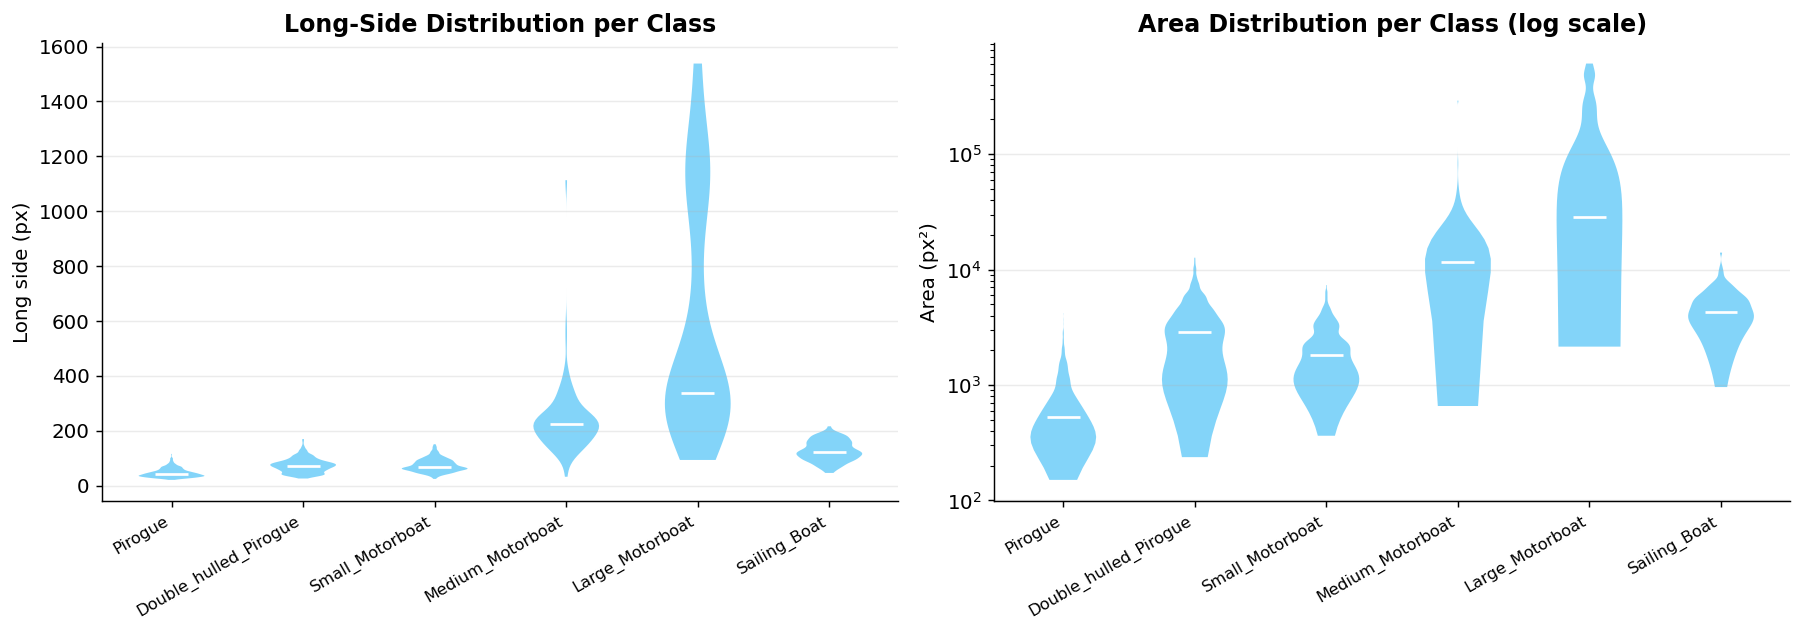

In [10]:
def shoelace_area(pts):
    x = np.array([p[0] for p in pts])
    y = np.array([p[1] for p in pts])
    return 0.5 * abs(float(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1))))

def quad_sides(pts):
    return [np.hypot(pts[(i+1)%4][0] - pts[i][0], pts[(i+1)%4][1] - pts[i][1]) for i in range(4)]

class_stats: dict = defaultdict(lambda: {"long": [], "short": [], "area": []})

for split in SPLITS:
    for txt in (LABELS_ROOT / split).glob("*.txt"):
        for line in txt.read_text().splitlines():
            line = line.strip()
            if not line:
                continue
            parts  = line.split()
            cid    = int(parts[0])
            coords = list(map(float, parts[1:9]))
            pts_px = [(coords[2*k] * TILE_SIZE, coords[2*k+1] * TILE_SIZE) for k in range(4)]
            sides  = quad_sides(pts_px)
            class_stats[cid]["long"].append(max(sides))
            class_stats[cid]["short"].append(min(sides))
            class_stats[cid]["area"].append(shoelace_area(pts_px))

size_rows = []
for cid, stats in sorted(class_stats.items()):
    if not stats["long"]:
        continue
    size_rows.append({
        "Class ID":        cid,
        "Class":           CLASS_NAMES[cid],
        "Count":           len(stats["long"]),
        "Long mean (px)":  np.mean(stats["long"]),
        "Long std":        np.std(stats["long"]),
        "Short mean (px)": np.mean(stats["short"]),
        "Short std":       np.std(stats["short"]),
        "Area mean (px²)": np.mean(stats["area"]),
        "Aspect ratio":    np.mean(np.array(stats["long"]) / np.array(stats["short"])),
    })

df_sizes = pd.DataFrame(size_rows).round(2)
display(df_sizes)

# ── Violin plots of long-side distribution per class ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_data  = [np.array(class_stats[cid]["long"])  for cid in sorted(class_stats)]
plot_data2 = [np.array(class_stats[cid]["area"])  for cid in sorted(class_stats)]
cls_labels = [CLASS_NAMES[cid] for cid in sorted(class_stats)]

for ax, data, title, ylabel in zip(
    axes,
    [plot_data, plot_data2],
    ["Long-Side Distribution per Class", "Area Distribution per Class (log scale)"],
    ["Long side (px)", "Area (px²)"]
):
    parts = ax.violinplot(data, showmedians=True, showextrema=False)
    for i, pc in enumerate(parts["bodies"]):
        pc.set_alpha(0.7)
    parts["cmedians"].set_color("white")
    ax.set_xticks(range(1, len(cls_labels) + 1))
    ax.set_xticklabels(cls_labels, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.grid(axis="y", alpha=0.25)

axes[1].set_yscale("log")
plt.tight_layout()
plt.show()